# Lecture 11 (B10): IRBC with DEQNs

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §Chapter 3 (International real business cycle)  
**Notebook role:** core  
**Original live-course source:** `lectures/day3/code/01_IRBC_DEQN.ipynb`  
**Course author:** Simon Scheidegger  
**License:** see repository `LICENSE` (MIT, code) and `LICENSE-content.md` (CC0 1.0, content).

In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


> **Smoke mode.** This notebook is long-running at production settings. The cell above sets `RUN_MODE="smoke"` so that the bound branch in the first hyperparameter cell below caps epochs / batch size / sample count to keep CPU runtime under ~3 minutes. To reproduce paper-quality results, switch to `"teaching"` or `"production"` (GPU recommended). See `COURSE_MAP.md` for the convention.

# Solving the IRBC Model with Deep Equilibrium Nets

*Companion notebook to **Day 3 — IRBC, NAS, Loss Normalization** (Chapters 3–4 of the lecture script).*

*Author: Simon Scheidegger (HEC Lausanne and Grantham Institute, LSE) — [course repository](https://github.com/sischei/Deep_Learning_for_Solving_And_Estimating_Dynamic_Economic_Models).*

**Notebook 4** — International Real Business Cycle Model

## Model Summary

We solve an $N$-country IRBC model featuring:
- **Complete markets** with heterogeneous Pareto weights
- **Irreversible investment** ($I^j \geq 0$) enforced via Fischer–Burmeister complementarity
- **Capital adjustment costs** $\Gamma^j = \frac{\kappa}{2} k^j (k^{j\prime}/k^j - 1)^2$
- **AR(1) TFP** with country-specific and aggregate shocks

The equilibrium system has $2N+1$ equations: $N$ Euler equations, 1 aggregate resource constraint, and $N$ Fischer–Burmeister conditions.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import itertools

plt.rcParams['font.size'] = 13
%matplotlib inline

# Reproducibility
import os
os.makedirs("../figures", exist_ok=True)
SEED = 0
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"Eager mode: {tf.executing_eagerly()}")


2026-02-13 15:01:12.625874: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770991272.649258  264980 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770991272.655580  264980 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-13 15:01:12.674965: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.18.0
Eager mode: True


## 1. Model Description

### Preferences
Each country $j = 1, \ldots, N$ has CRRA utility:
$$u^j(c) = \frac{c^{1-1/\gamma_j}}{1-1/\gamma_j}$$
where $\gamma_j$ is the intertemporal elasticity of substitution, linearly spaced in $[\gamma_{\min}, \gamma_{\max}]$.

### Production
$$Y^j = A_{\text{tfp}} \exp(z^j) (k^j)^\zeta, \qquad A_{\text{tfp}} = \frac{1 - \beta(1-\delta)}{\zeta \beta}$$

### TFP Process
$$z^{j\prime} = \rho_z z^j + \sigma_e(\varepsilon^j + \varepsilon^{\text{agg}}), \quad \varepsilon^j, \varepsilon^{\text{agg}} \sim \mathcal{N}(0,1)$$

### Adjustment Costs
$$\Gamma^j = \frac{\kappa}{2} k^j \left(\frac{k^{j\prime}}{k^j} - 1\right)^2$$

### Equilibrium Conditions
1. **Euler equations** (relative error form, one per country):
$$\frac{\beta \mathbb{E}[\lambda' \cdot \text{MPK}^{j\prime} - (1-\delta)\mu^{j\prime}] + \mu^j}{\lambda(1 + \Gamma_{k'})} - 1 = 0$$

2. **Aggregate Resource Constraint (ARC):**
$$\sum_{j=1}^N [Y^j + (1-\delta)k^j - k^{j\prime} - \Gamma^j - c^j] = 0$$

3. **Fischer–Burmeister complementarity** (one per country):
$$\text{FB}(\mu^j, I^j) = \mu^j + I^j - \sqrt{(\mu^j)^2 + (I^j)^2 + \varepsilon} = 0$$

where $c^j = (\lambda/\tau^j)^{-\gamma_j}$ from the consumption FOC, and $I^j = k^{j\prime} - (1-\delta)k^j$.

In [2]:
# ============================================================
# Parameters
# ============================================================
N_COUNTRIES = 2

# Preferences
beta = 0.99
gamma_min = 0.25
gamma_max = 1.0

# Production
zeta = 0.36
delta = 0.01

# TFP process
rho_z = 0.95
sigma_e = 0.01

# Adjustment costs
kappa = 0.5

# Steady state
k_ss = 1.0

# Derived: TFP calibration
A_tfp = (1.0 - beta * (1.0 - delta)) / (zeta * beta)

# Country-specific risk aversion parameters
if N_COUNTRIES == 1:
    gammas = [gamma_min]
else:
    gammas = [gamma_min + i * (gamma_max - gamma_min) / (N_COUNTRIES - 1)
              for i in range(N_COUNTRIES)]

# Pareto weights: tau_j = (A_tfp - delta)^(1/gamma_j); chosen so that
# at the symmetric SS (c_ss = A_tfp - delta) every country shares the same lambda_ss = 1.
taus = [(A_tfp - delta) ** (1.0 / g) for g in gammas]

# Dimensions
n_states = 2 * N_COUNTRIES       # [k_1,...,k_N, z_1,...,z_N]
n_policies = 2 * N_COUNTRIES + 1 # [kp_1,...,kp_N, lambda, mu_1,...,mu_N]
n_shocks = N_COUNTRIES + 1       # N country-specific + 1 aggregate

print(f"N_COUNTRIES = {N_COUNTRIES}")
print(f"A_tfp = {A_tfp:.6f}")
print(f"gammas = {gammas}")
print(f"taus = {[f'{t:.6f}' for t in taus]}")
print(f"States: {n_states}, Policies: {n_policies}, Shocks: {n_shocks}")


N_COUNTRIES = 2
A_tfp = 0.055836
gammas = [0.25, 1.0]
taus = ['0.000010', '0.055836']
States: 4, Policies: 5, Shocks: 3


## 2. Steady State Verification

At steady state: $z^j = 0$, $k^j = k_{ss} = 1$, $\mu^j = 0$ (irreversibility not binding).

We verify that the ARC and Euler equations are satisfied.

In [3]:
# Steady state quantities
Y_ss = A_tfp * np.exp(0.0) * k_ss**zeta
I_ss = delta * k_ss
adj_cost_ss = 0.0  # k'/k = 1 at steady state

# Consumption per country at steady state
# lambda_ss from Euler: lambda_ss * 1 = beta * lambda_ss * MPK_ss + 0
# => MPK_ss = 1/beta
# MPK_ss = 1 - delta + zeta * A_tfp * k_ss^(zeta-1) - 0 = 1/beta (by A_tfp calibration)
MPK_ss = 1.0 - delta + zeta * A_tfp * k_ss**(zeta - 1) - 0.0

# Total resources per country = Y_ss + (1-delta)*k_ss - k_ss - 0
resources_per_country = Y_ss + (1.0 - delta) * k_ss - k_ss - adj_cost_ss
c_ss_per_country = resources_per_country  # ARC: total resources = total consumption

# Check lambda_ss: from c = (lambda/tau)^(-gamma)
# For each country: c_ss = (lambda_ss / tau_j)^(-gamma_j)
# => lambda_ss = tau_j * c_ss^(-1/gamma_j)
lambda_ss_values = [taus[j] * c_ss_per_country**(-1.0/gammas[j]) for j in range(N_COUNTRIES)]

print("=== Steady State ===")
print(f"A_tfp = {A_tfp:.6f}")
print(f"Y_ss = {Y_ss:.6f}")
print(f"I_ss = {I_ss:.6f}")
print(f"c_ss = {c_ss_per_country:.6f}")
print(f"MPK_ss = {MPK_ss:.6f}, 1/beta = {1.0/beta:.6f}")
print(f"lambda_ss from each country: {[f'{v:.6f}' for v in lambda_ss_values]}")
print(f"ARC check: N*(Y_ss - I_ss - c_ss) = {N_COUNTRIES*(Y_ss - I_ss - c_ss_per_country):.2e}")

=== Steady State ===
A_tfp = 0.055836
Y_ss = 0.055836
I_ss = 0.010000
c_ss = 0.045836
MPK_ss = 1.010101, 1/beta = 1.010101
lambda_ss from each country: ['2.202061', '1.218168']
ARC check: N*(Y_ss - I_ss - c_ss) = -4.16e-17


## 3. Gauss–Hermite Quadrature

We use Gauss–Hermite quadrature for the $N+1$ shocks. With $Q$ nodes per dimension, the tensor product gives $Q^{N+1}$ total quadrature points.

In [4]:
# Gauss-Hermite quadrature
Q = 3  # nodes per dimension
nodes_1d, weights_1d = np.polynomial.hermite.hermgauss(Q)
nodes_1d = nodes_1d * np.sqrt(2.0)       # scale for N(0,1)
weights_1d = weights_1d / np.sqrt(np.pi)  # normalize weights

# Tensor product for n_shocks dimensions
indices = list(itertools.product(range(Q), repeat=n_shocks))
quad_nodes = np.array([[nodes_1d[idx] for idx in combo] for combo in indices])
quad_weights = np.array([np.prod([weights_1d[idx] for idx in combo]) for combo in indices])

# Convert to TF tensors
quad_nodes_tf = tf.constant(quad_nodes, dtype=tf.float32)
quad_weights_tf = tf.constant(quad_weights, dtype=tf.float32)

n_quad_total = len(quad_weights)
print(f"Q = {Q} per dimension, n_shocks = {n_shocks}")
print(f"Total quadrature nodes: {n_quad_total}")
print(f"Weights sum to: {np.sum(quad_weights):.6f} (should be 1.0)")

Q = 3 per dimension, n_shocks = 3
Total quadrature nodes: 27
Weights sum to: 1.000000 (should be 1.0)


2026-02-13 15:01:15.894137: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 4. Neural Network Architecture

The neural network maps the state vector $\mathbf{s} \in \mathbb{R}^{2N}$ to the policy vector in $\mathbb{R}^{2N+1}$:

$$\mathcal{N}_\rho: (k^1, \ldots, k^N, z^1, \ldots, z^N) \mapsto (k^{1\prime}, \ldots, k^{N\prime}, \lambda, \mu^1, \ldots, \mu^N)$$

- 2 hidden layers × 64 units with **swish** activation
- Output layer with **softplus** to ensure all policies are strictly positive

In [5]:
def build_network():
    nn = keras.Sequential([
        keras.layers.Dense(64, activation='swish', input_shape=(n_states,)),
        keras.layers.Dense(64, activation='swish'),
        keras.layers.Dense(n_policies, activation='softplus')
    ])
    return nn

nn = build_network()
print(nn.summary())

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,805 (18.77 KB)

 Trainable params: 4,805 (18.77 KB)

 Non-trainable params: 0 (0.00 B)

None


## 5. Model Equations

We implement all economic functions needed for the equilibrium conditions. Each function operates on tensors with a batch dimension.

In [6]:
# Small epsilon for numerical stability
EPS_SAFE = 1e-10

# ============================================================
# Production
# ============================================================
def production(k, z):
    """Y = A_tfp * exp(z) * k^zeta"""
    return A_tfp * tf.exp(z) * tf.pow(tf.maximum(k, EPS_SAFE), zeta)

def production_k(k, z):
    """dY/dk = zeta * A_tfp * exp(z) * k^(zeta-1)"""
    return zeta * A_tfp * tf.exp(z) * tf.pow(tf.maximum(k, EPS_SAFE), zeta - 1.0)

# ============================================================
# Consumption from FOC: c_j = (lambda / tau_j)^(-gamma_j)
# ============================================================
def consumption(lamb, j):
    """Consumption for country j from complete-markets FOC."""
    return tf.pow(lamb / taus[j], -gammas[j])

# ============================================================
# Adjustment costs: Gamma = 0.5 * kappa * k * (k'/k - 1)^2
# ============================================================
def adj_cost(k, kp):
    k_safe = tf.maximum(k, EPS_SAFE)
    j = kp / k_safe - 1.0
    return 0.5 * kappa * j * j * k_safe

def adj_cost_kp(k, kp):
    """dGamma/dk' = kappa * (k'/k - 1)"""
    k_safe = tf.maximum(k, EPS_SAFE)
    return kappa * (kp / k_safe - 1.0)

def adj_cost_k(k, kp):
    """dGamma/dk = -0.5 * kappa * (k'/k - 1) * (k'/k + 1)"""
    k_safe = tf.maximum(k, EPS_SAFE)
    j = kp / k_safe - 1.0
    return -0.5 * kappa * j * (j + 2.0)

# ============================================================
# Marginal product of capital
# MPK = 1 - delta + F_k(k,z) - dGamma/dk(k,k')
# ============================================================
def mpk(k, z, kp):
    return 1.0 - delta + production_k(k, z) - adj_cost_k(k, kp)

# ============================================================
# Investment: I = k' - (1-delta)*k
# ============================================================
def investment(k, kp):
    return kp - (1.0 - delta) * k

# ============================================================
# Fischer-Burmeister complementarity
# FB(mu, I) = mu + I - sqrt(mu^2 + I^2 + eps^2)
# ============================================================
def fischer_burmeister(mu, I_val, eps=1e-4):
    return mu + I_val - tf.sqrt(mu * mu + I_val * I_val + eps * eps)

print("Model equations defined.")

Model equations defined.


## 6. Cost Function

The cost function evaluates all $2N+1$ equilibrium residuals and returns their mean squared sum.

### Policy and state accessors

The state vector layout: $[k_1, \ldots, k_N, z_1, \ldots, z_N]$

The policy vector layout: $[k_1', \ldots, k_N', \lambda, \mu_1, \ldots, \mu_N]$

In [7]:
# ============================================================
# Accessor helpers for state and policy tensors
# ============================================================
def get_k(states, j):
    """Capital for country j (0-indexed) from state tensor."""
    return states[:, j:j+1]

def get_z(states, j):
    """Log TFP for country j (0-indexed) from state tensor."""
    return states[:, N_COUNTRIES + j : N_COUNTRIES + j + 1]

def get_kp(policies, j):
    """Next-period capital for country j (0-indexed) from policy tensor."""
    return policies[:, j:j+1]

def get_lamb(policies):
    """ARC multiplier lambda from policy tensor."""
    return policies[:, N_COUNTRIES:N_COUNTRIES+1]

def get_mu(policies, j):
    """Irreversibility multiplier for country j (0-indexed)."""
    return policies[:, N_COUNTRIES + 1 + j : N_COUNTRIES + 2 + j]

In [8]:
@tf.function
def compute_cost(states, nn):
    """
    Compute mean squared equilibrium residuals.
    Returns: total_loss, dict of individual residuals
    """
    batch_size = tf.shape(states)[0]
    policies = nn(states)

    # Current lambda
    lamb_t = get_lamb(policies)

    # ---- Euler equations (one per country) ----
    euler_residuals = []
    for j in range(N_COUNTRIES):
        k_j = get_k(states, j)
        kp_j = get_kp(policies, j)
        mu_j = get_mu(policies, j)

        # LHS: lambda * (1 + dGamma/dk')
        dGamma_dkp = adj_cost_kp(k_j, kp_j)
        euler_lhs = lamb_t * (1.0 + dGamma_dkp)

        # Expectation: E[lambda' * MPK' - (1-delta) * mu']
        expectation_j = tf.zeros_like(lamb_t)

        for q in range(n_quad_total):
            w_q = quad_weights_tf[q]
            shock_q = quad_nodes_tf[q]  # [n_shocks]

            # Next-period state
            next_state_parts = []
            # Capital: k' from policy
            for jj in range(N_COUNTRIES):
                next_state_parts.append(get_kp(policies, jj))
            # TFP: z' = rho_z * z + sigma_e * (eps_j + eps_agg)
            eps_agg = shock_q[n_shocks - 1]
            for jj in range(N_COUNTRIES):
                z_jj = get_z(states, jj)
                z_next = rho_z * z_jj + sigma_e * (shock_q[jj] + eps_agg)
                next_state_parts.append(z_next)

            next_state = tf.concat(next_state_parts, axis=1)
            next_policies = nn(next_state)

            # lambda' and MPK' and mu' for country j
            lamb_next = get_lamb(next_policies)
            k_next_j = get_k(next_state, j)
            z_next_j = get_z(next_state, j)
            kp_next_j = get_kp(next_policies, j)
            mu_next_j = get_mu(next_policies, j)

            mpk_next_j = mpk(k_next_j, z_next_j, kp_next_j)
            integrand = lamb_next * mpk_next_j - (1.0 - delta) * mu_next_j
            expectation_j = expectation_j + w_q * integrand

        # RHS: beta * E[...] + mu
        euler_rhs = beta * expectation_j + mu_j

        # Relative error
        euler_res = euler_rhs / tf.maximum(euler_lhs, EPS_SAFE) - 1.0
        euler_residuals.append(euler_res)

    # ---- Aggregate Resource Constraint ----
    arc_residual = tf.zeros_like(lamb_t)
    for j in range(N_COUNTRIES):
        k_j = get_k(states, j)
        z_j = get_z(states, j)
        kp_j = get_kp(policies, j)

        Y_j = production(k_j, z_j)
        c_j = consumption(lamb_t, j)
        Gamma_j = adj_cost(k_j, kp_j)

        arc_residual = arc_residual + (Y_j + (1.0 - delta) * k_j - kp_j - Gamma_j - c_j)

    # ---- Fischer-Burmeister complementarity ----
    fb_residuals = []
    for j in range(N_COUNTRIES):
        k_j = get_k(states, j)
        kp_j = get_kp(policies, j)
        mu_j = get_mu(policies, j)
        I_j = investment(k_j, kp_j)
        fb_j = fischer_burmeister(mu_j, I_j)
        fb_residuals.append(fb_j)

    # ---- Total loss ----
    total_sq = tf.zeros_like(lamb_t)
    for e in euler_residuals:
        total_sq = total_sq + e ** 2
    total_sq = total_sq + arc_residual ** 2
    for fb in fb_residuals:
        total_sq = total_sq + fb ** 2

    loss = tf.reduce_mean(total_sq)

    return loss, euler_residuals, arc_residual, fb_residuals

In [9]:
# Gradient function
def grad(states, nn):
    with tf.GradientTape() as tape:
        loss, _, _, _ = compute_cost(states, nn)
    return loss, tape.gradient(loss, nn.trainable_variables)

In [10]:
# Helper: create a fresh optimizer
def make_optimizer(lr=1e-3):
    return tf.keras.optimizers.Adam(learning_rate=lr)

## 7. Sampling Strategies

### Phase 1: Exogenous sampling
Draw states uniformly from a rectangular domain around the steady state.

### Phase 2: Simulation-based sampling
Simulate the model forward using the current policy network, and train on the resulting states.

In [11]:
# Bounds for exogenous sampling
k_lb, k_ub = 0.5, 1.5
z_bound = 3.0 * sigma_e / (1.0 - rho_z)  # ~3 std devs of unconditional dist
z_lb, z_ub = -z_bound, z_bound

def get_training_data_exogenous(n_data):
    """Sample states uniformly from [k_lb, k_ub] x [z_lb, z_ub] for each country."""
    parts = []
    # Capital for each country
    for j in range(N_COUNTRIES):
        parts.append(tf.random.uniform([n_data, 1], k_lb, k_ub))
    # TFP for each country
    for j in range(N_COUNTRIES):
        parts.append(tf.random.uniform([n_data, 1], z_lb, z_ub))
    return tf.concat(parts, axis=1)

print(f"Exogenous bounds: k in [{k_lb}, {k_ub}], z in [{z_lb:.4f}, {z_ub:.4f}]")

Exogenous bounds: k in [0.5, 1.5], z in [-0.6000, 0.6000]


In [12]:
@tf.function
def simulate_single_step(states, nn):
    """Simulate one step forward using the policy network and random shocks."""
    policies = nn(states)
    batch_size = tf.shape(states)[0]

    # Draw random shocks: N country-specific + 1 aggregate
    eps = tf.random.normal([batch_size, n_shocks])
    eps_agg = eps[:, n_shocks-1:n_shocks]

    next_parts = []
    # Next capital: k' from policy
    for j in range(N_COUNTRIES):
        next_parts.append(get_kp(policies, j))
    # Next TFP: z' = rho_z * z + sigma_e * (eps_j + eps_agg)
    for j in range(N_COUNTRIES):
        z_j = get_z(states, j)
        eps_j = eps[:, j:j+1]
        z_next = rho_z * z_j + sigma_e * (eps_j + eps_agg)
        next_parts.append(z_next)

    return tf.concat(next_parts, axis=1)


def sim_periods(start_states, nn, n_periods):
    """Simulate n_periods steps, return all states."""
    n_tracks = start_states.shape[0]
    all_states = np.zeros((n_periods, n_tracks, n_states), dtype=np.float32)
    all_states[0] = start_states.numpy() if isinstance(start_states, tf.Tensor) else start_states

    current = tf.constant(all_states[0])
    for t in range(1, n_periods):
        current = simulate_single_step(current, nn)
        all_states[t] = current.numpy()

    return all_states


def get_training_data_simulation(start_states, nn, n_periods):
    """Simulate and reshape into (n_tracks * n_periods, n_states) training data."""
    sim = sim_periods(start_states, nn, n_periods)
    n_tracks = start_states.shape[0]
    end_states = sim[-1]  # last time step as starting point for next episode
    training_data = sim.reshape(n_tracks * n_periods, n_states)
    return tf.constant(training_data), tf.constant(end_states)

## 8. Approach A: Exogenous Sampling Only

Train a **fresh** network using uniformly sampled states (no simulation).

A (exogenous) | Episode     0 | Loss [log10] = 0.1590


A (exogenous) | Episode   500 | Loss [log10] = -2.2746


A (exogenous) | Episode  1000 | Loss [log10] = -2.4314


A (exogenous) | Episode  1500 | Loss [log10] = -2.8579


A (exogenous) | Episode  2000 | Loss [log10] = -3.2054


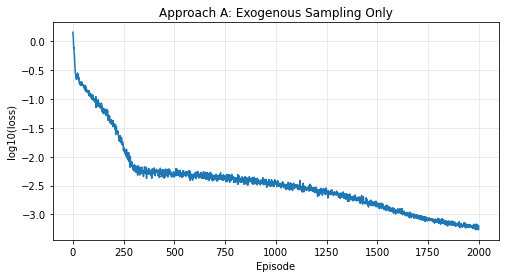

Final loss A: 6.23e-04


In [13]:
# ---- Approach A: Exogenous sampling, fresh network ----
nn_A = build_network()
opt_A = make_optimizer(lr=1e-3)
loss_A = []
num_episodes = 2001
n_data = 256

for ep in range(num_episodes):
    X = get_training_data_exogenous(n_data)
    loss, grads_val = grad(X, nn_A)
    opt_A.apply_gradients(zip(grads_val, nn_A.trainable_variables))
    loss_A.append(loss.numpy())

    if ep % 500 == 0:
        print(f"A (exogenous) | Episode {ep:5d} | Loss [log10] = {np.log10(loss.numpy()):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(np.log10(np.array(loss_A)))
plt.xlabel('Episode'); plt.ylabel('log10(loss)')
plt.title('Approach A: Exogenous Sampling Only')
plt.grid(True, alpha=0.3)
plt.show()
print(f"Final loss A: {loss_A[-1]:.2e}")

## 9. Approach B: Simulation-Based Sampling Only

Train a **fresh** network using simulation-based sampling from scratch (no exogenous warm-up).

B (simulation) | Episode     0 | Loss [log10] = -0.8173


B (simulation) | Episode   500 | Loss [log10] = -1.1584


B (simulation) | Episode  1000 | Loss [log10] = -3.2484


B (simulation) | Episode  1500 | Loss [log10] = -3.4963


B (simulation) | Episode  2000 | Loss [log10] = -3.5257


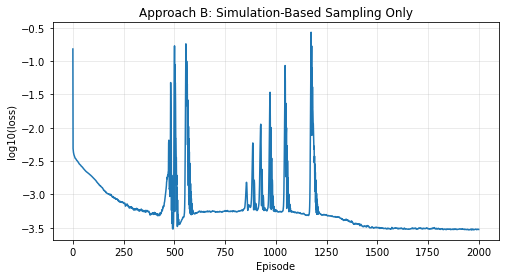

Final loss B: 2.98e-04


In [14]:
# ---- Approach B: Simulation-based sampling, fresh network ----
nn_B = build_network()
opt_B = make_optimizer(lr=1e-3)
loss_B = []
n_tracks = 128
n_sim_periods = 5

# Initialize near steady state
def make_start_states(n_tracks):
    ss = np.zeros((n_tracks, n_states), dtype=np.float32)
    for j in range(N_COUNTRIES):
        ss[:, j] = k_ss
    ss[:, :N_COUNTRIES] += np.random.uniform(-0.1, 0.1, (n_tracks, N_COUNTRIES)).astype(np.float32)
    ss[:, N_COUNTRIES:] += np.random.uniform(-0.01, 0.01, (n_tracks, N_COUNTRIES)).astype(np.float32)
    return tf.constant(ss)

X_start_B = make_start_states(n_tracks)

for ep in range(num_episodes):
    X, X_start_B = get_training_data_simulation(X_start_B, nn_B, n_sim_periods)
    loss, grads_val = grad(X, nn_B)
    opt_B.apply_gradients(zip(grads_val, nn_B.trainable_variables))
    loss_B.append(loss.numpy())

    if ep % 500 == 0:
        print(f"B (simulation) | Episode {ep:5d} | Loss [log10] = {np.log10(loss.numpy()):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(np.log10(np.array(loss_B)))
plt.xlabel('Episode'); plt.ylabel('log10(loss)')
plt.title('Approach B: Simulation-Based Sampling Only')
plt.grid(True, alpha=0.3)
plt.show()
print(f"Final loss B: {loss_B[-1]:.2e}")

## 10. Approach C: Steady-State Pre-Training + Simulation-Based Sampling

**Key idea:** Before starting the DEQN training, we *pre-train* the network on the analytically known steady-state solution. This gives the network sensible initial policies, so training starts much closer to the solution.

At steady state ($z^j = 0$, $k^j = k_{ss}$):
- $k^{j\prime} = k_{ss}$ (replacement investment)
- $\lambda = \lambda_{ss}$ (computed analytically)
- $\mu^j \approx 0$ (irreversibility not binding)

We generate states near the steady state and train the network via supervised MSE loss to match these known targets.

Pre-training target: [1.0000000e+00 1.0000000e+00 2.2020614e+00 1.0000000e-06 1.0000000e-06]
Pre-train | Episode    0 | MSE = 6.79e-01


Pre-train | Episode  100 | MSE = 2.16e-02


Pre-train | Episode  200 | MSE = 9.68e-03


Pre-train | Episode  300 | MSE = 3.63e-03


Pre-train | Episode  400 | MSE = 6.33e-04


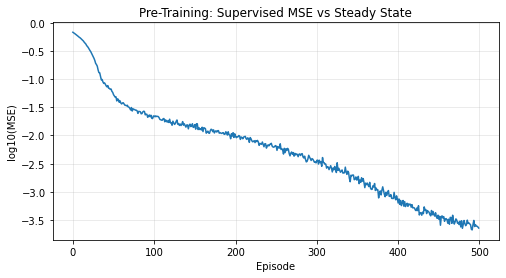


After pre-training, nn_C at steady state: [0.99733484 1.0020683  2.2053719  0.01229943 0.01282005]
Target:                                    [1.0000000e+00 1.0000000e+00 2.2020614e+00 1.0000000e-06 1.0000000e-06]


In [15]:
# ---- Approach C: Pre-training + simulation-based, fresh network ----
nn_C = build_network()
opt_C = make_optimizer(lr=1e-3)

# ========================================
# Step 1: Steady-state pre-training
# ========================================

# Compute the steady-state lambda (same for all countries by calibration)
lambda_ss = taus[0] * c_ss_per_country ** (-1.0 / gammas[0])

# Target policy at steady state: [k_ss, ..., k_ss, lambda_ss, 0, ..., 0]
target_ss = np.zeros(n_policies, dtype=np.float32)
for j in range(N_COUNTRIES):
    target_ss[j] = k_ss          # kp_j = k_ss
target_ss[N_COUNTRIES] = lambda_ss  # lambda
for j in range(N_COUNTRIES):
    target_ss[N_COUNTRIES + 1 + j] = 1e-6  # mu_j ≈ 0

print(f"Pre-training target: {target_ss}")

# Supervised pre-training: MSE between nn output and steady-state target
loss_pretrain = []
n_pretrain = 500

for ep in range(n_pretrain):
    # Generate states near steady state
    X_pre = get_training_data_exogenous(256)

    # Target: broadcast steady-state policy to batch
    target_batch = tf.constant(np.tile(target_ss, (256, 1)))

    with tf.GradientTape() as tape:
        predictions = nn_C(X_pre)
        mse = tf.reduce_mean((predictions - target_batch) ** 2)

    grads_pre = tape.gradient(mse, nn_C.trainable_variables)
    opt_C.apply_gradients(zip(grads_pre, nn_C.trainable_variables))
    loss_pretrain.append(mse.numpy())

    if ep % 100 == 0:
        print(f"Pre-train | Episode {ep:4d} | MSE = {mse.numpy():.2e}")

plt.figure(figsize=(8, 4))
plt.plot(np.log10(np.array(loss_pretrain)))
plt.xlabel('Episode'); plt.ylabel('log10(MSE)')
plt.title('Pre-Training: Supervised MSE vs Steady State')
plt.grid(True, alpha=0.3)
plt.show()

# Check what the network outputs at steady state after pre-training
ss_input = np.zeros((1, n_states), dtype=np.float32)
for j in range(N_COUNTRIES):
    ss_input[0, j] = k_ss
print(f"\nAfter pre-training, nn_C at steady state: {nn_C(ss_input).numpy().flatten()}")
print(f"Target:                                    {target_ss}")

C (pretrain+sim) | Episode     0 | Loss [log10] = -2.4632


C (pretrain+sim) | Episode   500 | Loss [log10] = -3.5147


C (pretrain+sim) | Episode  1000 | Loss [log10] = -3.4685


C (pretrain+sim) | Episode  1500 | Loss [log10] = -3.5377


C (pretrain+sim) | Episode  2000 | Loss [log10] = -3.4804


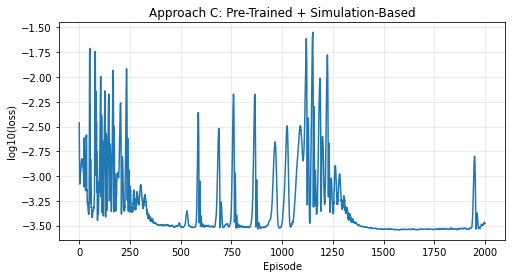

Final loss C: 3.31e-04


In [16]:
# ========================================
# Step 2: DEQN training with simulation-based sampling
# ========================================
loss_C = []
X_start_C = make_start_states(n_tracks)

# Reset optimizer for DEQN phase (fresh Adam state)
opt_C_deqn = make_optimizer(lr=1e-3)

for ep in range(num_episodes):
    X, X_start_C = get_training_data_simulation(X_start_C, nn_C, n_sim_periods)
    loss, grads_val = grad(X, nn_C)
    opt_C_deqn.apply_gradients(zip(grads_val, nn_C.trainable_variables))
    loss_C.append(loss.numpy())

    if ep % 500 == 0:
        print(f"C (pretrain+sim) | Episode {ep:5d} | Loss [log10] = {np.log10(loss.numpy()):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(np.log10(np.array(loss_C)))
plt.xlabel('Episode'); plt.ylabel('log10(loss)')
plt.title('Approach C: Pre-Trained + Simulation-Based')
plt.grid(True, alpha=0.3)
plt.show()
print(f"Final loss C: {loss_C[-1]:.2e}")

## 12. Approach D: ReLoBRaLo Loss Normalization + Simulation-Based Sampling

The DEQN loss has $2N+1 = 5$ components (Euler$_1$, Euler$_2$, ARC, FB$_1$, FB$_2$) that may operate at **different scales**. With equal weighting (Approaches A–C), the gradient is dominated by whichever component has the largest residual — the network "ignores" smaller-scale components.

**ReLoBRaLo** (Relative Loss Balancing with Random Lookback; [Bischof & Kraus, 2021](https://arxiv.org/abs/2110.09813)) adaptively reweights the components:

1. **Step-wise weights** via softmax of loss ratios:
$$\hat{w}_i^{(t)} = \operatorname{softmax}_i\!\left(\frac{\mathcal{L}_i^{(t)}}{T \cdot \mathcal{L}_i^{(t-1)}}\right) \cdot K$$

2. **Baseline weights** using initial losses (random lookback):
$$\hat{w}_i^{(0)} = \operatorname{softmax}_i\!\left(\frac{\mathcal{L}_i^{(t)}}{T \cdot \mathcal{L}_i^{(0)}}\right) \cdot K$$

3. **Exponential moving average** combining history and current:
$$w_i^{(t)} = \alpha\bigl[\rho \, w_i^{(t-1)} + (1-\rho)\,\hat{w}_i^{(0)}\bigr] + (1-\alpha)\,\hat{w}_i^{(t)}$$

Parameters: $T = 1$ (temperature), $\alpha = 0.999$ (smoothing), $\rho \sim \text{Bernoulli}(0.999)$ (random lookback).

This approach starts from a **fresh** network (no pre-training) to isolate the effect of loss normalization.

D (ReLoBRaLo) | Episode     0 | Loss [log10] = -0.8080
   Weights: Euler 1=1.00  Euler 2=1.00  ARC=1.00  FB 1=1.00  FB 2=1.00


D (ReLoBRaLo) | Episode   500 | Loss [log10] = -2.1736
   Weights: Euler 1=0.99  Euler 2=1.00  ARC=1.02  FB 1=0.98  FB 2=1.01


D (ReLoBRaLo) | Episode  1000 | Loss [log10] = -3.3228
   Weights: Euler 1=0.87  Euler 2=0.94  ARC=2.23  FB 1=0.51  FB 2=0.45


D (ReLoBRaLo) | Episode  1500 | Loss [log10] = -3.5066
   Weights: Euler 1=0.90  Euler 2=1.43  ARC=0.90  FB 1=0.91  FB 2=0.86


D (ReLoBRaLo) | Episode  2000 | Loss [log10] = -3.5154
   Weights: Euler 1=0.96  Euler 2=1.28  ARC=0.96  FB 1=1.13  FB 2=0.68


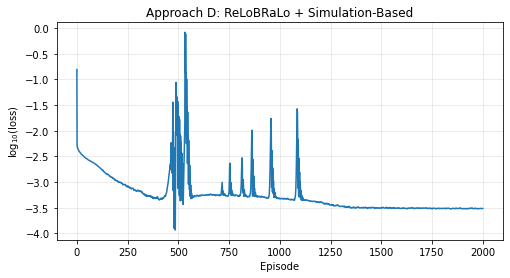

Final loss D: 3.05e-04


In [17]:
# ---- Approach D: ReLoBRaLo + Simulation-Based, fresh network ----
nn_D = build_network()
opt_D = make_optimizer(lr=1e-3)

# ReLoBRaLo hyperparameters (Bischof & Kraus, 2021)
T_relo = 1.0        # softmax temperature
alpha_relo = 0.999   # exponential moving average rate
rho_prob = 0.999     # random lookback probability

n_comp = 2 * N_COUNTRIES + 1  # 5 components: 2 Euler + 1 ARC + 2 FB
comp_labels = ([f'Euler {j+1}' for j in range(N_COUNTRIES)]
               + ['ARC']
               + [f'FB {j+1}' for j in range(N_COUNTRIES)])

# Initialize weights and loss trackers
weights_relo = np.ones(n_comp, dtype=np.float64)
prev_comp = np.ones(n_comp, dtype=np.float64)
init_comp = None

# Random lookback schedule: binary per episode (1 = use history, 0 = use baseline)
np.random.seed(42)
rho_schedule = (np.random.uniform(size=num_episodes + 2) < rho_prob).astype(np.float64)
# Alpha schedule: epoch 0 → pure momentum, epoch 1 → pure adaptive, then blend
alpha_sched = np.full(num_episodes + 2, alpha_relo, dtype=np.float64)
alpha_sched[0] = 1.0
alpha_sched[1] = 0.0

loss_D = []
weight_history = []
comp_loss_history = []

X_start_D = make_start_states(n_tracks)

for ep in range(num_episodes):
    X, X_start_D = get_training_data_simulation(X_start_D, nn_D, n_sim_periods)

    # --- Compute component losses and weighted gradient ---
    with tf.GradientTape() as tape:
        _, euler_res, arc_res, fb_res = compute_cost(X, nn_D)

        # Individual component losses (2N+1 = 5)
        comp_tf = []
        for j in range(N_COUNTRIES):
            comp_tf.append(tf.reduce_mean(euler_res[j] ** 2))
        comp_tf.append(tf.reduce_mean(arc_res ** 2))
        for j in range(N_COUNTRIES):
            comp_tf.append(tf.reduce_mean(fb_res[j] ** 2))

        # Weighted loss (weights are constants — no gradient through them)
        weighted_loss = tf.add_n([float(weights_relo[i]) * comp_tf[i]
                                  for i in range(n_comp)])

    grads_val = tape.gradient(weighted_loss, nn_D.trainable_variables)
    opt_D.apply_gradients(zip(grads_val, nn_D.trainable_variables))

    # Track unweighted loss for fair comparison with A, B, C
    comp_np = np.array([l.numpy() for l in comp_tf], dtype=np.float64)
    loss_D.append(float(comp_np.sum()))
    weight_history.append(weights_relo.copy())
    comp_loss_history.append(comp_np.copy())

    # --- ReLoBRaLo weight update ---
    a = alpha_sched[ep]
    r = rho_schedule[ep]

    if ep == 1:
        init_comp = comp_np.copy()

    if ep >= 2 and init_comp is not None:
        # Step-wise weights: softmax(L_i^t / (L_i^{t-1} * T)) * K
        logits_s = comp_np / (prev_comp * T_relo + 1e-12)
        logits_s -= logits_s.max()  # numerical stability
        exp_s = np.exp(logits_s)
        lambs_hat = n_comp * exp_s / exp_s.sum()

        # Baseline weights: softmax(L_i^t / (L_i^0 * T)) * K
        logits_b = comp_np / (init_comp * T_relo + 1e-12)
        logits_b -= logits_b.max()
        exp_b = np.exp(logits_b)
        lambs0_hat = n_comp * exp_b / exp_b.sum()

        # Combined update
        weights_relo = (r * a * weights_relo
                        + (1 - r) * a * lambs0_hat
                        + (1 - a) * lambs_hat)

    prev_comp = comp_np.copy()

    if ep % 500 == 0:
        print(f"D (ReLoBRaLo) | Episode {ep:5d} | Loss [log10] = {np.log10(loss_D[-1]):.4f}")
        w_str = '  '.join(f'{comp_labels[i]}={weights_relo[i]:.2f}' for i in range(n_comp))
        print(f"   Weights: {w_str}")

plt.figure(figsize=(8, 4))
plt.plot(np.log10(np.array(loss_D)))
plt.xlabel('Episode'); plt.ylabel('log$_{10}$(loss)')
plt.title('Approach D: ReLoBRaLo + Simulation-Based')
plt.grid(True, alpha=0.3)
plt.show()
print(f"Final loss D: {loss_D[-1]:.2e}")

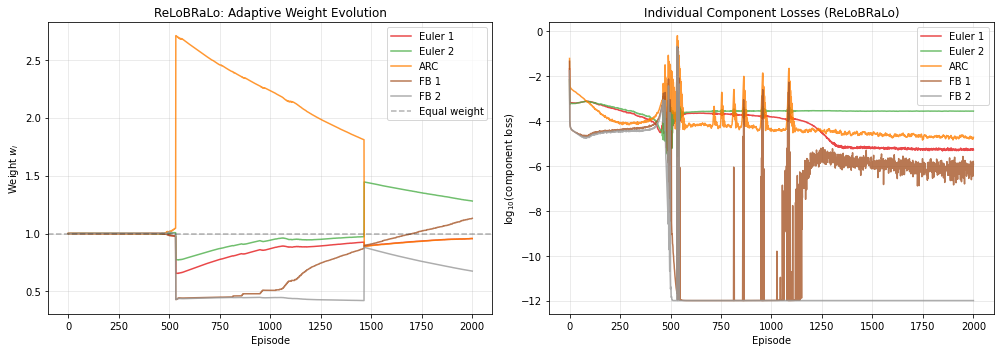

Final ReLoBRaLo weights and component losses:
  Euler 1   : w = 0.9565,  loss = 5.27e-06
  Euler 2   : w = 1.2801,  loss = 2.80e-04
  ARC       : w = 0.9569,  loss = 1.89e-05
  FB 1      : w = 1.1312,  loss = 1.15e-06
  FB 2      : w = 0.6753,  loss = 8.88e-16


In [18]:
# ---- ReLoBRaLo: Weight evolution and component analysis ----
weight_arr = np.array(weight_history)
comp_arr = np.array(comp_loss_history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Weight evolution over training
colors = plt.cm.Set1(np.linspace(0, 1, n_comp))
for i in range(n_comp):
    ax1.plot(weight_arr[:, i], label=comp_labels[i], color=colors[i], alpha=0.8)
ax1.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, label='Equal weight')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Weight $w_i$')
ax1.set_title('ReLoBRaLo: Adaptive Weight Evolution')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: Individual component losses (log scale)
for i in range(n_comp):
    ax2.plot(np.log10(comp_arr[:, i] + 1e-12), label=comp_labels[i],
             color=colors[i], alpha=0.8)
ax2.set_xlabel('Episode')
ax2.set_ylabel('log$_{10}$(component loss)')
ax2.set_title('Individual Component Losses (ReLoBRaLo)')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final weights and component losses
print("Final ReLoBRaLo weights and component losses:")
for i in range(n_comp):
    print(f"  {comp_labels[i]:10s}: w = {weights_relo[i]:.4f},  loss = {comp_arr[-1, i]:.2e}")

## 13. Comparison of All Four Approaches

We compare the convergence of the DEQN loss across the four training strategies, all starting from freshly initialized networks.

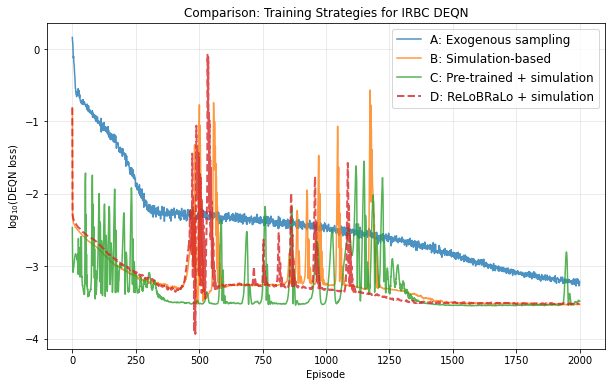

Final losses (unweighted, for fair comparison):
  A (exogenous):              6.23e-04
  B (simulation):             2.98e-04
  C (pre-trained+simulation): 3.31e-04
  D (ReLoBRaLo+simulation):   3.05e-04


In [19]:
# ---- Comparison plot: All four approaches ----
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.log10(np.array(loss_A)), label='A: Exogenous sampling', alpha=0.8)
ax.plot(np.log10(np.array(loss_B)), label='B: Simulation-based', alpha=0.8)
ax.plot(np.log10(np.array(loss_C)), label='C: Pre-trained + simulation', alpha=0.8)
ax.plot(np.log10(np.array(loss_D)), label='D: ReLoBRaLo + simulation',
        alpha=0.8, linestyle='--', linewidth=2)
ax.set_xlabel('Episode')
ax.set_ylabel('log$_{10}$(DEQN loss)')
ax.set_title('Comparison: Training Strategies for IRBC DEQN')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.savefig('../figures/irbc_4approach_loss.pdf', bbox_inches='tight')
plt.savefig('../figures/irbc_4approach_loss.png', dpi=180, bbox_inches='tight')
plt.show()

print("Final losses (unweighted, for fair comparison):")
print(f"  A (exogenous):              {loss_A[-1]:.2e}")
print(f"  B (simulation):             {loss_B[-1]:.2e}")
print(f"  C (pre-trained+simulation): {loss_C[-1]:.2e}")
print(f"  D (ReLoBRaLo+simulation):   {loss_D[-1]:.2e}")


## 14. Discussion: Why Loss Normalization Matters for DEQNs

### The Scale Problem in Multi-Equation Equilibria

The IRBC equilibrium system has $2N+1 = 5$ loss components with inherently **different scales**:

| Component | Formula | Typical Scale |
|-----------|---------|---------------|
| Euler equations | Relative error: $\beta \mathbb{E}[\cdots] / (\lambda(1+\Gamma_{k'})) - 1$ | $\sim 10^{-2}$ to $10^{-1}$ |
| ARC | Absolute: $\sum_j [Y^j - c^j - I^j - \Gamma^j]$ | $\sim 10^{-1}$ to $10^{0}$ |
| Fischer–Burmeister | $\mu + I - \sqrt{\mu^2 + I^2 + \varepsilon}$ | depends on $\mu, I$ |

With **equal weighting** (Approaches A–C), the gradient is dominated by the component with the largest squared residual:
$$\frac{\partial \mathcal{L}}{\partial \boldsymbol{\theta}} \approx \frac{\partial \mathcal{L}_{\max}}{\partial \boldsymbol{\theta}}$$

This means:
- Components that converge quickly **continue** to receive disproportionate gradient signal
- Components that struggle (often the most economically important ones) are **neglected**
- The optimizer solves a *single-component* problem instead of the full equilibrium system

### How ReLoBRaLo Helps

ReLoBRaLo rebalances gradients automatically:
1. **Tracking loss ratios** — components whose loss ratio $\mathcal{L}_i^{(t)} / \mathcal{L}_i^{(t-1)}$ is high (lagging behind) receive higher weight
2. **Random lookback** — periodically comparing to initial losses $\mathcal{L}_i^{(0)}$ prevents weight drift over long training
3. **Exponential smoothing** — ensures stable weight trajectories, avoiding oscillations

The **weight evolution plot** above shows how ReLoBRaLo identifies under-learned components and increases their contribution to the total gradient, while down-weighting components that are already well-approximated.

### Combining Approaches

In practice, the four strategies are **orthogonal improvements** that can be combined:
- **Pre-training** (Approach C) → better initialization
- **Loss normalization** (Approach D) → better gradient balance
- **Simulation-based sampling** → focus on the ergodic set

The ideal setup for a production DEQN solver would combine all three: pre-train on the steady state, then train with simulation-based sampling and ReLoBRaLo loss normalization.

### Reference
Bischof, R. & Kraus, M. (2021). *Multi-objective loss balancing for physics-informed deep learning.* arXiv:2110.09813.

In [20]:
# ---- Per-equation residuals for best network (C) ----
nn = nn_C  # use best network for all diagnostics below

n_test = 2000
X_start_test = make_start_states(n_tracks)
X_test, _ = get_training_data_simulation(X_start_test, nn, n_test // n_tracks + 1)
X_test = X_test[:n_test]

loss_test, euler_res, arc_res, fb_res = compute_cost(X_test, nn)

print(f"Test set loss (C): {loss_test.numpy():.2e}")
print("\nPer-equation residuals (mean |.|, max |.|):")
for j in range(N_COUNTRIES):
    e = np.abs(euler_res[j].numpy())
    print(f"  Euler {j+1}:  mean = {np.mean(e):.2e},  max = {np.max(e):.2e}")
arc_abs = np.abs(arc_res.numpy())
print(f"  ARC:      mean = {np.mean(arc_abs):.2e},  max = {np.max(arc_abs):.2e}")
for j in range(N_COUNTRIES):
    f = np.abs(fb_res[j].numpy())
    print(f"  FB {j+1}:    mean = {np.mean(f):.2e},  max = {np.max(f):.2e}")

Test set loss (C): 2.80e-01

Per-equation residuals (mean |.|, max |.|):
  Euler 1:  mean = 4.64e-02,  max = 1.55e-01
  Euler 2:  mean = 1.95e-02,  max = 1.35e-01
  ARC:      mean = 3.06e-01,  max = 1.83e+00
  FB 1:    mean = 2.21e-02,  max = 1.20e-01
  FB 2:    mean = 4.66e-04,  max = 7.35e-03


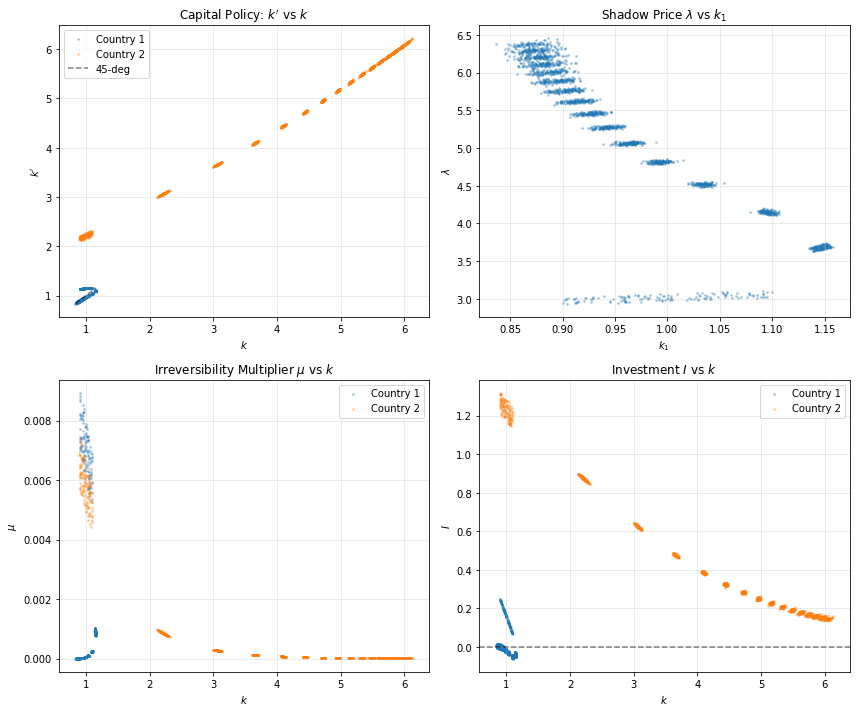

In [21]:
# Policy function plots (using best network nn = nn_C)
P_test = nn(X_test).numpy()
X_np = X_test.numpy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# k' vs k for each country
for j in range(N_COUNTRIES):
    axes[0, 0].scatter(X_np[:, j], P_test[:, j], s=3, alpha=0.3, label=f"Country {j+1}")
k_range = np.linspace(X_np[:, 0].min(), X_np[:, 0].max(), 10)
axes[0, 0].plot(k_range, k_range, 'k--', alpha=0.5, label='45-deg')
axes[0, 0].set_xlabel('$k$'); axes[0, 0].set_ylabel("$k'$")
axes[0, 0].set_title("Capital Policy: $k'$ vs $k$")
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# lambda vs k1
axes[0, 1].scatter(X_np[:, 0], P_test[:, N_COUNTRIES], s=3, alpha=0.3)
axes[0, 1].set_xlabel('$k_1$'); axes[0, 1].set_ylabel('$\\lambda$')
axes[0, 1].set_title('Shadow Price $\\lambda$ vs $k_1$')
axes[0, 1].grid(True, alpha=0.3)

# mu vs k for each country
for j in range(N_COUNTRIES):
    axes[1, 0].scatter(X_np[:, j], P_test[:, N_COUNTRIES + 1 + j],
                       s=3, alpha=0.3, label=f"Country {j+1}")
axes[1, 0].set_xlabel('$k$'); axes[1, 0].set_ylabel('$\\mu$')
axes[1, 0].set_title('Irreversibility Multiplier $\\mu$ vs $k$')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# Investment vs k for each country
for j in range(N_COUNTRIES):
    I_j = P_test[:, j] - (1.0 - delta) * X_np[:, j]
    axes[1, 1].scatter(X_np[:, j], I_j, s=3, alpha=0.3, label=f"Country {j+1}")
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('$k$'); axes[1, 1].set_ylabel('$I$')
axes[1, 1].set_title('Investment $I$ vs $k$')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

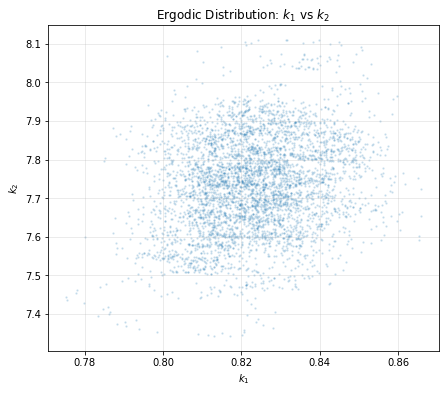

In [22]:
# Ergodic distribution: k1 vs k2
if N_COUNTRIES >= 2:
    # Simulate long path
    n_long = 5000
    ss_start = np.zeros((1, n_states), dtype=np.float32)
    for j in range(N_COUNTRIES):
        ss_start[0, j] = k_ss
    long_sim = sim_periods(tf.constant(ss_start), nn, n_long)
    long_sim = long_sim[500:]  # burn-in

    plt.figure(figsize=(7, 6))
    plt.scatter(long_sim[:, 0, 0], long_sim[:, 0, 1], s=2, alpha=0.15)
    plt.xlabel('$k_1$')
    plt.ylabel('$k_2$')
    plt.title('Ergodic Distribution: $k_1$ vs $k_2$')
    plt.grid(True, alpha=0.3)
    plt.show()

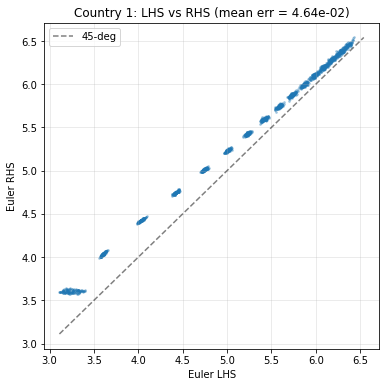

Country 1: Mean relative Euler error = 4.64e-02, Max = 1.55e-01


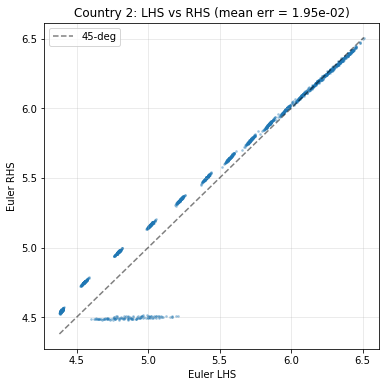

Country 2: Mean relative Euler error = 1.95e-02, Max = 1.35e-01


In [23]:
# Euler LHS vs RHS validation
policies_test = nn(X_test)

for j in range(N_COUNTRIES):
    k_j = get_k(X_test, j)
    kp_j = get_kp(policies_test, j)
    mu_j = get_mu(policies_test, j)
    lamb_t = get_lamb(policies_test)

    dGamma_dkp = adj_cost_kp(k_j, kp_j)
    euler_lhs = lamb_t * (1.0 + dGamma_dkp)

    # Compute expectation
    expectation_j = tf.zeros_like(lamb_t)
    for q in range(n_quad_total):
        w_q = quad_weights_tf[q]
        shock_q = quad_nodes_tf[q]
        eps_agg = shock_q[n_shocks - 1]

        next_state_parts = []
        for jj in range(N_COUNTRIES):
            next_state_parts.append(get_kp(policies_test, jj))
        for jj in range(N_COUNTRIES):
            z_jj = get_z(X_test, jj)
            z_next = rho_z * z_jj + sigma_e * (shock_q[jj] + eps_agg)
            next_state_parts.append(z_next)

        next_state = tf.concat(next_state_parts, axis=1)
        next_policies = nn(next_state)

        lamb_next = get_lamb(next_policies)
        k_next_j = get_k(next_state, j)
        z_next_j = get_z(next_state, j)
        kp_next_j = get_kp(next_policies, j)
        mu_next_j = get_mu(next_policies, j)

        mpk_next_j = mpk(k_next_j, z_next_j, kp_next_j)
        integrand = lamb_next * mpk_next_j - (1.0 - delta) * mu_next_j
        expectation_j = expectation_j + w_q * integrand

    euler_rhs = beta * expectation_j + mu_j

    lhs_np = euler_lhs.numpy().flatten()
    rhs_np = euler_rhs.numpy().flatten()
    rel_err = np.abs(rhs_np / np.maximum(lhs_np, 1e-10) - 1.0)

    plt.figure(figsize=(6, 6))
    plt.scatter(lhs_np, rhs_np, s=3, alpha=0.3)
    lim = [min(lhs_np.min(), rhs_np.min()), max(lhs_np.max(), rhs_np.max())]
    plt.plot(lim, lim, 'k--', alpha=0.5, label='45-deg')
    plt.xlabel('Euler LHS')
    plt.ylabel('Euler RHS')
    plt.title(f'Country {j+1}: LHS vs RHS (mean err = {np.mean(rel_err):.2e})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f'../figures/irbc_euler_validation_country{j+1}.pdf', bbox_inches='tight')
    plt.savefig(f'../figures/irbc_euler_validation_country{j+1}.png', dpi=180, bbox_inches='tight')
    plt.show()

    print(f"Country {j+1}: Mean relative Euler error = {np.mean(rel_err):.2e}, "
          f"Max = {np.max(rel_err):.2e}")


## Summary

We solved the $N$-country IRBC model with Deep Equilibrium Nets and compared four training strategies:

1. **Approach A** (exogenous sampling): trains on uniformly drawn states — simple but wastes effort in unreachable regions.

2. **Approach B** (simulation-based): trains on the ergodic distribution — focuses on relevant states but starts from random policies.

3. **Approach C** (pre-trained + simulation): first pre-trains the network to match the analytical steady state, then switches to simulation-based DEQN training. The pre-training gives the network a sensible initialization.

4. **Approach D** (ReLoBRaLo + simulation): uses adaptive loss normalization (ReLoBRaLo) to reweight the $2N+1$ equilibrium components during training, ensuring that no single component dominates the gradient.

### Key Takeaways
- **Sampling strategy matters**: Simulation-based sampling (B) outperforms uniform exogenous sampling (A) by focusing on the ergodic set.
- **Initialization matters**: A few hundred episodes of supervised pre-training (C) costs almost nothing but starts the optimization in the right neighborhood.
- **Loss balancing matters**: When equilibrium conditions have different scales, adaptive loss normalization (D) prevents gradient dominance and can improve convergence.
- These improvements are **orthogonal** and can be combined for best results.

### Extensions
- Scale to $N = 10, 50, 100$ countries (replace GH tensor product with monomial rules or QMC)
- Combine pre-training + ReLoBRaLo for best-of-both-worlds
- GPU parallelization with Horovod/MPI for large-scale problems

### References
- Azinovic, Gaegauf & Scheidegger (2022), *International Economic Review* 63(4), 1471–1525
- Brumm, Krause, Schaab & Scheidegger (2021), *SSRN Working Paper*
- Bischof & Kraus (2021), *Multi-objective loss balancing for physics-informed deep learning*, arXiv:2110.09813